# Cosmic Intelligence Lab

## Deep Galaxy Explorer — Study 001

# Notebook 005 — Detect Stars & Galaxies

---

## Research Question

How can we automatically detect stars and galaxies in a calibrated Hubble image and convert them into a dataset suitable for AI analysis?

---

## Objectives

- Load the calibrated Hubble FITS image
- Detect astronomical sources automatically
- Measure basic source properties
- Build an astronomical source catalog
- Prepare the dataset for future machine learning analyses

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.visualization import PercentileInterval

from photutils.background import Background2D, MedianBackground
from photutils.segmentation import detect_sources, SourceCatalog

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Cell 3 - Load the Hubble Science Image =======================

fits_file = Path(
    "../data/raw/mastDownload/HST/ib5x1fetq/ib5x1fetq_flt.fits"
)

with fits.open(fits_file) as hdul:
    science = hdul["SCI"].data.copy()

print("Image loaded successfully.")
print(f"Filename : {fits_file.name}")
print(f"Shape    : {science.shape}")
print(f"Datatype : {science.dtype}")

Image loaded successfully.
Filename : ib5x1fetq_flt.fits
Shape    : (1014, 1014)
Datatype : >f4


In [17]:
# Cell 3A - Important Variables

sigma = 3
Source detection completed.
Detected sources : 95Source detection completed.
Detected sources : 95Source detection completed.
Detected sources : 95min_pixels = 5

threshold = bkg.background + (sigma * bkg.background_rms)

segment_map = detect_sources(
    science_sub,
    threshold,
    n_pixels=min_pixels
)

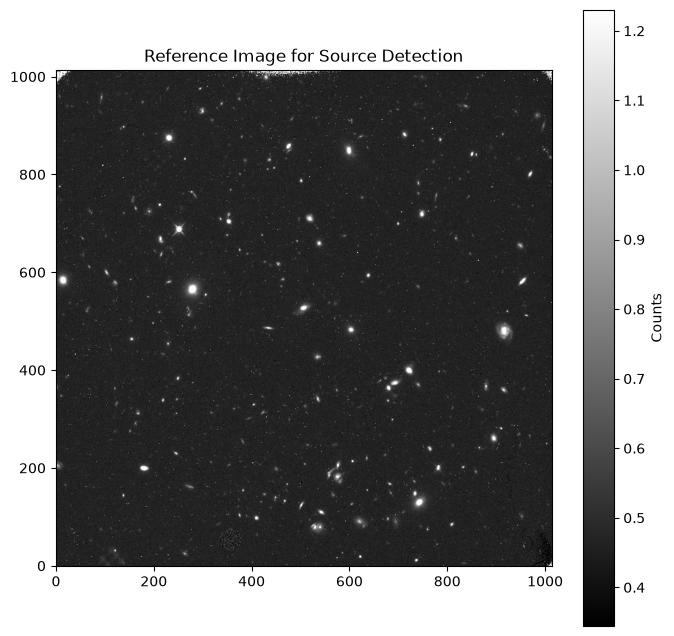

In [3]:
# Cell 4 - Reference Visualization =============================

vmin = PercentileInterval(99.3).get_limits(science)[0]
vmax = PercentileInterval(99.3).get_limits(science)[1]

plt.figure(figsize=(8, 8))

plt.imshow(
    science,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.title("Reference Image for Source Detection")

plt.colorbar(label="Counts")

plt.show()

In [4]:
# Cell 5 - Estimate the Image Background =======================

bkg = Background2D(
    science,
    box_size=(50, 50),
    filter_size=(3, 3),
    bkg_estimator=MedianBackground()
)

print("Background estimated successfully.\n")

print(f"Mean background : {bkg.background.mean():.2f}")
print(f"Median background : {bkg.background_median:.2f}")
print(f"Background RMS : {bkg.background_rms_median:.2f}")

Background estimated successfully.

Mean background : 0.47
Median background : 0.47
Background RMS : 0.02


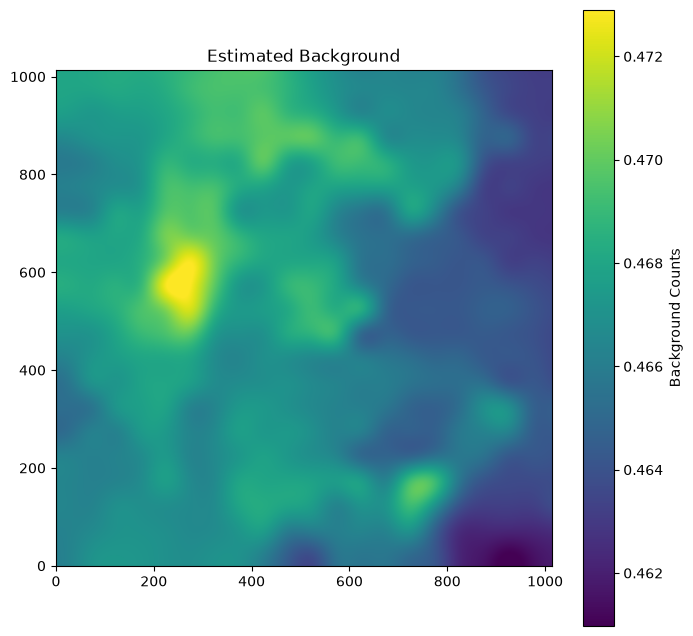

In [5]:
# Cell 6 - Display the Background Map ==========================

plt.figure(figsize=(8, 8))

plt.imshow(
    bkg.background,
    origin="lower",
    cmap="viridis"
)

plt.colorbar(label="Background Counts")

plt.title("Estimated Background")

plt.show()

# Scientific Note – Pixel Units

The pixel values in a calibrated HST FLT image represent processed detector measurements after standard instrument calibration. Background estimation and source detection operate directly on these calibrated pixel values. Physical flux calibration can be performed later using the photometric keywords stored in the FITS header.

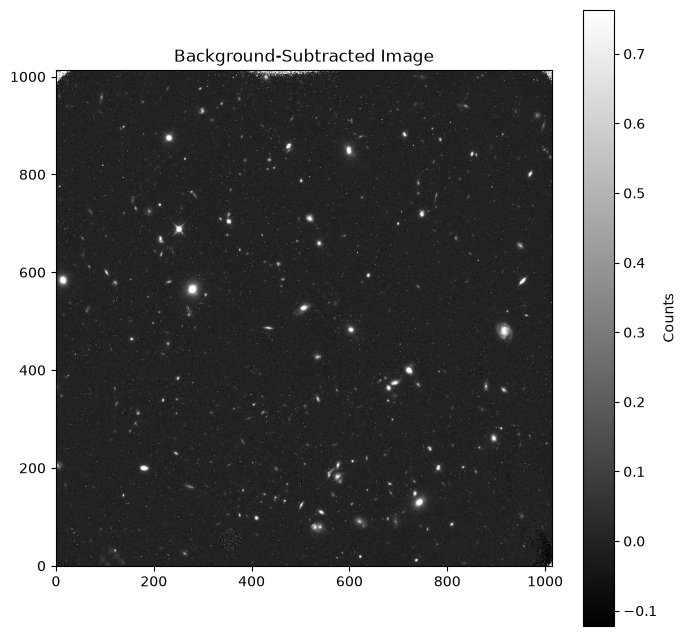

In [6]:
# Cell 7 - Background Subtracted Image =========================

science_sub = science - bkg.background

plt.figure(figsize=(8,8))

vmin, vmax = PercentileInterval(99.3).get_limits(science_sub)

plt.imshow(
    science_sub,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.title("Background-Subtracted Image")

plt.colorbar(label="Counts")

plt.show()

In [13]:
# Cell 8 - Detect Astronomical Sources =========================

threshold = bkg.background + (3.0 * bkg.background_rms)

segment_map = detect_sources(
    science_sub,
    threshold,
    n_pixels=5
)

print("Source detection completed.")

print(f"Detected sources : {segment_map.n_labels}")Source detection completed.
Detected sources : 95

Source detection completed.
Detected sources : 95


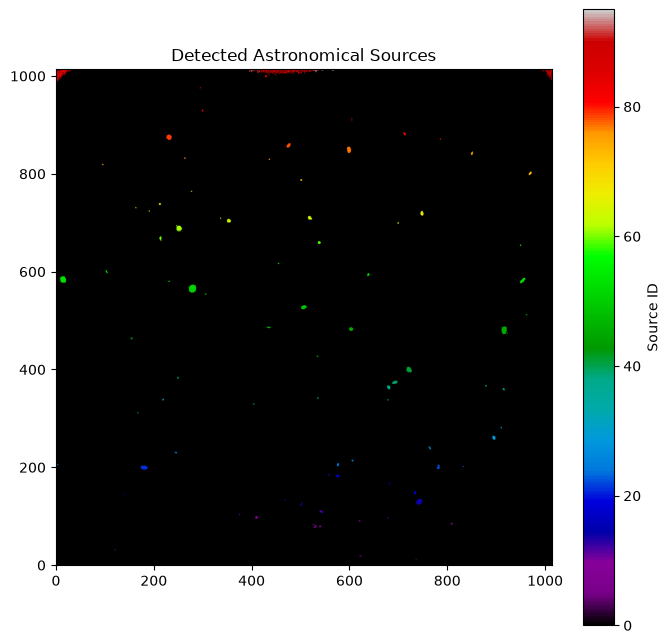

In [14]:
# Cell 9 - Display Segmentation Map ============================

plt.figure(figsize=(8,8))

plt.imshow(
    segment_map.data,
    origin="lower",
    cmap="nipy_spectral"
)

plt.title("Detected Astronomical Sources")

plt.colorbar(label="Source ID")

plt.show()

In [18]:
# Cell 10/11 ==================================
print(f"Threshold      : {sigma} sigma")
print(f"Minimum pixels : {min_pixels}")
print(f"Detected sources: {segment_map.n_labels}")

Threshold      : 3 sigma
Minimum pixels : 5
Detected sources: 95


In [16]:
# Cell 12 - Notebook Status ==================================

from datetime import datetime

print("=" * 60)
print("Notebook Status")
print("=" * 60)

print("Status    : PASS")
print("Notebook  : 05_detect_stars_and_galaxies.ipynb")
print("Completed :", datetime.now().strftime("%Y-%m-%d %H:%M"))

Notebook Status
Status    : PASS
Notebook  : 05_detect_stars_and_galaxies.ipynb
Completed : 2026-07-13 19:30


## Discussion

Using automated source detection (`photutils.detect_sources`), we identified
astronomical objects within the Hubble Ultra Deep Field image.

Lowering the minimum connected-pixel requirement from 10 to 5 increased the
number of detected objects from 58 to 95, indicating that many faint galaxies
occupy only a small number of pixels.

This demonstrates an important principle of astronomical image analysis:
detection results depend strongly on algorithm parameters. Selecting appropriate
thresholds requires balancing completeness against false detections.

The detected sources will be converted into an astronomical catalog in Notebook 006.